In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import openpyxl

meshes = [("Zeer groffe mesh", r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh6_results.xlsx"),
          ("Groffe mesh", r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh5_results.xlsx"),
    ("Medium Mesh", r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh1_results.xlsx"),
    ("Fijne mesh", r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh2_results.xlsx"),
    ("Zeer fijne mesh", r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh3_results.xlsx"),
    
    
]


In [35]:

target_heading = 0         # bijvoorbeeld 0.0, 45.0, 90.0
dof = "heave"                 # surge, sway, heave, roll, pitch, yaw
quantity = "phase"        # amplitude of phase

rao_map = {
    "surge": {
        "amplitude": {"col": 3, "label": "Surge RAO amplitude [m/m]"},
        "phase":     {"col": 4, "label": "Surge RAO phase [deg]"},
    },
    "sway": {
        "amplitude": {"col": 5, "label": "Sway RAO amplitude [m/m]"},
        "phase":     {"col": 6, "label": "Sway RAO phase [deg]"},
    },
    "heave": {
        "amplitude": {"col": 7, "label": "Heave RAO amplitude [m/m]"},
        "phase":     {"col": 8, "label": "Heave RAO phase [deg]"},
    },
    "roll": {
        "amplitude": {"col": 9,  "label": "Roll RAO amplitude [rad/m]"},
        "phase":     {"col": 10, "label": "Roll RAO phase [deg]"},
    },
    "pitch": {
        "amplitude": {"col": 11, "label": "Pitch RAO amplitude [rad/m]"},
        "phase":     {"col": 12, "label": "Pitch RAO phase [deg]"},
    },
    "yaw": {
        "amplitude": {"col": 13, "label": "Yaw RAO amplitude [rad/m]"},
        "phase":     {"col": 14, "label": "Yaw RAO phase [deg]"},
    },
}

if dof not in rao_map:
    raise ValueError(f"Onbekende dof '{dof}'. Kies uit: {list(rao_map.keys())}")

if quantity not in rao_map[dof]:
    raise ValueError("quantity moet 'amplitude' of 'phase' zijn")


if len(files) != len(mesh_labels):
    raise ValueError("Aantal files moet gelijk zijn aan aantal mesh_labels")



Zeer groffe mesh
Periods: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]
heave phase: [3.17163126e+02 2.41984797e+02 3.13990077e+02 3.04031907e+02
 4.71949677e+01 7.74274390e+00 2.61446095e+00 1.17207546e+00
 5.92495282e-01 3.22259992e-01 1.85191357e-01 1.11334594e-01
 6.95530383e-02 4.49287435e-02 2.99005425e-02 2.04500877e-02
 1.43504434e-02 1.03205099e-02 7.59918043e-03 5.72216519e-03]

Groffe mesh
Periods: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]
heave phase: [1.22534479e+02 2.43361037e+02 3.14598644e+02 1.02486286e+02
 4.73425787e+01 7.81117687e+00 2.67031430e+00 1.20655212e+00
 6.13026453e-01 3.34486624e-01 1.92619623e-01 1.15966726e-01
 7.25193055e-02 4.68756890e-02 3.12067427e-02 2.13434816e-02
 1.49722749e-02 1.07606098e-02 7.91587980e-03 5.95392754e-03]

Medium Mesh
Periods: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]
heave phase: [2.67457493e+02 2.48856091e+0

Exception ignored in: <function ZipFile.__del__ at 0x00000165DB3E4360>
Traceback (most recent call last):
  File "c:\Users\verav\miniconda3\envs\mude-week-2-6\Lib\zipfile\__init__.py", line 1940, in __del__
    self.close()
  File "c:\Users\verav\miniconda3\envs\mude-week-2-6\Lib\zipfile\__init__.py", line 1942, in close
    def close(self):

KeyboardInterrupt: 



Zeer fijne mesh
Periods: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]
heave phase: [8.62583423e+01 2.51357213e+02 3.17041703e+02 9.15029952e+01
 4.49250237e+01 7.65314846e+00 2.43078023e+00 1.01891474e+00
 4.91130234e-01 2.58806054e-01 1.45615429e-01 8.62918740e-02
 5.33808818e-02 3.42622961e-02 2.27251850e-02 1.55359769e-02
 1.09287025e-02 7.89929562e-03 5.85792757e-03 4.44901697e-03]


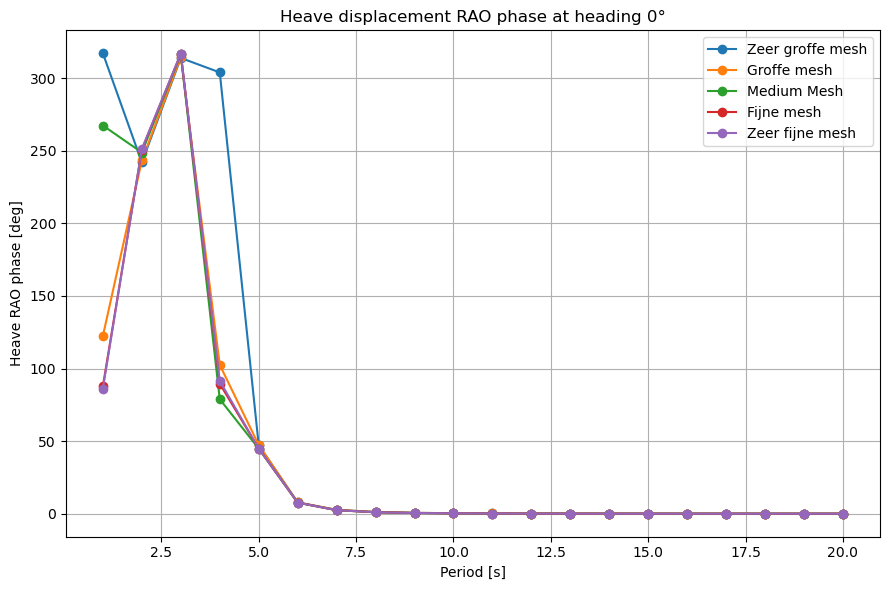

In [36]:
target_col = rao_map[dof][quantity]["col"]
y_label = rao_map[dof][quantity]["label"]
plot_title = f"{dof.capitalize()} displacement RAO {quantity} at heading {target_heading}°"


def read_rao_from_excel(file_path, sheet_name, target_heading, target_col):
    wb = openpyxl.load_workbook(file_path, data_only=True)
    ws = wb[sheet_name]

    periods = []
    values = []

    # data start op rij 8
    for r in range(8, ws.max_row + 1):
        heading = ws.cell(r, 1).value   # kolom A
        period = ws.cell(r, 2).value    # kolom B
        value = ws.cell(r, target_col).value

        if isinstance(heading, (int, float)) and isinstance(period, (int, float)):
            if abs(heading - target_heading) < 1e-9:
                periods.append(period)
                values.append(value if value is not None else np.nan)

    periods = np.array(periods, dtype=float)
    values = np.array(values, dtype=float)

    # sorteren op periode
    idx = np.argsort(periods)
    periods = periods[idx]
    values = values[idx]

    return periods, values

# =========================
# PLOT ALLE MESHES
# =========================
plt.figure(figsize=(9, 6))

for label, file in meshes:
    periods, values = read_rao_from_excel(
        file_path=file,
        sheet_name="Displacement RAOs",
        target_heading=target_heading,
        target_col=target_col
    )


    print(f"\n{label}")
    print("Periods:", periods)
    print(f"{dof} {quantity}:", values)

    plt.plot(periods, values, marker="o", label=label)

plt.xlabel("Period [s]")
plt.ylabel(y_label)
plt.title(plot_title)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()